<a href="https://colab.research.google.com/github/bernardarthur0123-netizen/foundation-/blob/main/01_CNN_Foundations_PyTorch_EN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 1 · CNN Foundations with PyTorch

**Topic:** What a convolution is, why CNNs work so well for images, and how to interpret filters, activation maps, and pooling.

**Level:** Master's in Deep Learning  
**Framework:** PyTorch

---

## Learning goals

By the end of this notebook, you will be able to:

1. Understand the difference between a dense neural network and a convolutional neural network.
2. Explain what **kernel**, **stride**, **padding**, and **pooling** do.
3. See a convolution almost manually first, and then with `torch.nn.Conv2d`.
4. Visually interpret filters and activation maps.
5. Connect the concept to real business use cases.

---

## Intuition

A CNN does not inspect an image “all at once”.  
It slides small windows called **filters** or **kernels** over the image.

Each filter learns to detect a pattern:
- horizontal edges
- vertical edges
- textures
- corners
- more abstract combinations in deeper layers

### Business analogy

Imagine a retail chain receiving shelf photos.
- A simple filter may detect vertical bottle edges.
- Another one may detect highly contrasted labels.
- Deeper layers may eventually recognize product families: drinks, dairy, cleaning products, and so on.

In other words, a CNN **builds visual knowledge hierarchically**.

In [1]:

import math
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F

torch.manual_seed(42)
np.random.seed(42)

## 1. Why not use only dense layers?

Suppose we have a small grayscale image of `64 x 64` pixels.

- Number of inputs = `64 * 64 = 4096`
- If we connect it to a dense layer with 512 neurons:
  - parameters = `4096 * 512 + 512`
  - that already exceeds **2 million** parameters

With real images, this scales poorly.

### Problems of a dense network in vision

1. **Too many parameters**
2. **It ignores spatial structure**
3. **It does not reuse local patterns**

By contrast, a CNN:
- looks at local regions
- shares weights
- preserves spatial relationships

That is the big idea.

In [2]:

image_size = 64 * 64
hidden_units = 512
params_dense = image_size * hidden_units + hidden_units
print(f"Parameters in a dense layer 4096 -> 512: {params_dense:,}")

Parameters in a dense layer 4096 -> 512: 2,097,664


In [3]:

conv_params = 8 * (1 * 3 * 3) + 8  # 8 filtros de 3x3 para una entrada de 1 canal
print(f"Parameters in a conv layer with 8 filters 3x3: {conv_params:,}")

Parameters in a conv layer with 8 filters 3x3: 80


Notice the difference:
- a dense layer learns many independent connections between pixels and neurons
- a convolutional layer learns **small reusable patterns**

---

## 2. Building an artificial “image”

To understand the mechanism, we start with small matrices.

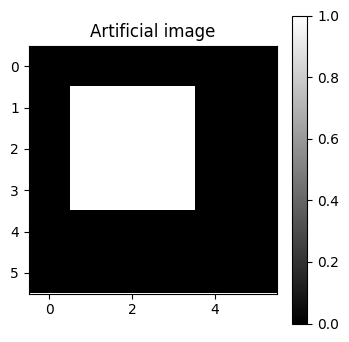

In [4]:

image = torch.tensor([
    [0., 0., 0., 0., 0., 0.],
    [0., 1., 1., 1., 0., 0.],
    [0., 1., 1., 1., 0., 0.],
    [0., 1., 1., 1., 0., 0.],
    [0., 0., 0., 0., 0., 0.],
    [0., 0., 0., 0., 0., 0.]
])

plt.figure(figsize=(4,4))
plt.imshow(image, cmap="gray")
plt.title("Artificial image")
plt.colorbar()
plt.show()

The bright central area can be interpreted as a simple object over a dark background.

Now we define two classic filters:
- vertical edge detector
- horizontal edge detector

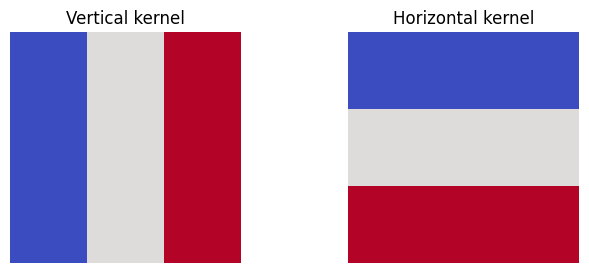

In [5]:

vertical_kernel = torch.tensor([
    [-1., 0., 1.],
    [-1., 0., 1.],
    [-1., 0., 1.]
])

horizontal_kernel = torch.tensor([
    [-1., -1., -1.],
    [ 0.,  0.,  0.],
    [ 1.,  1.,  1.]
])

fig, axes = plt.subplots(1, 2, figsize=(8, 3))
axes[0].imshow(vertical_kernel, cmap="coolwarm")
axes[0].set_title("Vertical kernel")
axes[1].imshow(horizontal_kernel, cmap="coolwarm")
axes[1].set_title("Horizontal kernel")
for ax in axes:
    ax.axis("off")
plt.show()

## 3. Convolution “by hand”

Let us implement a 2D convolution explicitly to see what happens at each position.

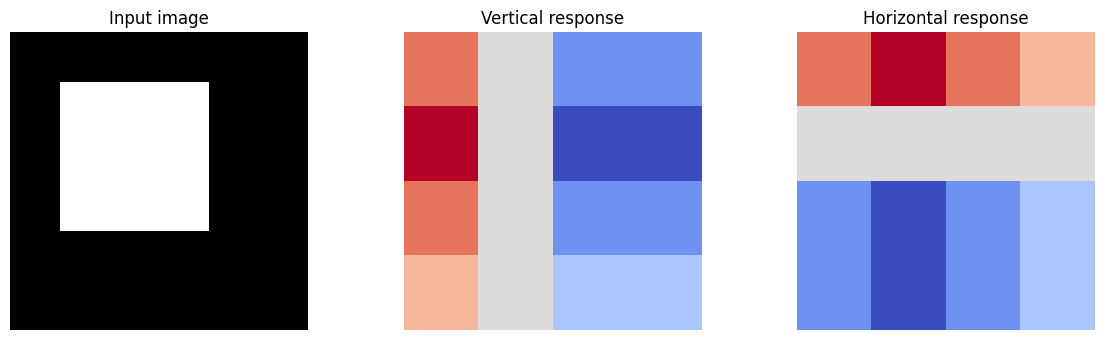

In [6]:

def manual_convolution2d(image_2d, kernel_2d, stride=1, padding=0):
    if padding > 0:
        image_2d = F.pad(image_2d, (padding, padding, padding, padding))

    h, w = image_2d.shape
    kh, kw = kernel_2d.shape

    out_h = (h - kh) // stride + 1
    out_w = (w - kw) // stride + 1

    output = torch.zeros((out_h, out_w))

    for i in range(out_h):
        for j in range(out_w):
            region = image_2d[i*stride:i*stride+kh, j*stride:j*stride+kw]
            output[i, j] = torch.sum(region * kernel_2d)

    return output

out_vertical = manual_convolution2d(image, vertical_kernel)
out_horizontal = manual_convolution2d(image, horizontal_kernel)

fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
axes[0].imshow(image, cmap="gray")
axes[0].set_title("Input image")
axes[1].imshow(out_vertical, cmap="coolwarm")
axes[1].set_title("Vertical response")
axes[2].imshow(out_horizontal, cmap="coolwarm")
axes[2].set_title("Horizontal response")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

### Interpretation

Large positive or negative values indicate that the filter found a pattern compatible with its shape.

- If the vertical kernel responds strongly, there is an important left-right change.
- If the horizontal kernel responds strongly, there is an important top-bottom change.

In a real CNN, **these kernels are not hand-written**: they are learned automatically during training.

## 4. The same idea with `nn.Conv2d`

In [7]:

conv = nn.Conv2d(in_channels=1, out_channels=2, kernel_size=3, bias=False)

with torch.no_grad():
    conv.weight[0, 0] = vertical_kernel
    conv.weight[1, 0] = horizontal_kernel

x = image.unsqueeze(0).unsqueeze(0)  # (batch, channels, height, width)
y = conv(x)

print("Input shape :", x.shape)
print("Output shape:", y.shape)

Input shape : torch.Size([1, 1, 6, 6])
Output shape: torch.Size([1, 2, 4, 4])


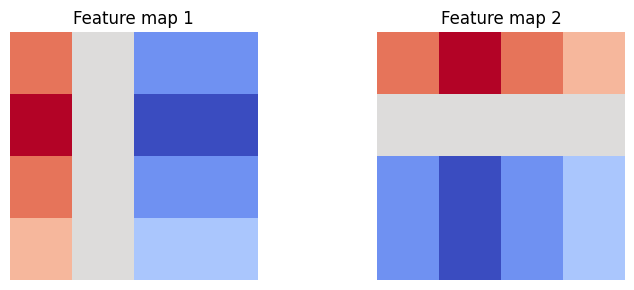

In [8]:

feature_maps = y.squeeze(0)

fig, axes = plt.subplots(1, 2, figsize=(8, 3))
axes[0].imshow(feature_maps[0].detach(), cmap="coolwarm")
axes[0].set_title("Feature map 1")
axes[1].imshow(feature_maps[1].detach(), cmap="coolwarm")
axes[1].set_title("Feature map 2")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

Here we see a key idea:

- **1 filter => 1 activation map**
- **many filters => many maps**

Those maps become the new representation of the image.

## 5. Stride and padding

In [9]:

conv_s1 = nn.Conv2d(1, 1, kernel_size=3, stride=1, padding=0, bias=False)
conv_s2 = nn.Conv2d(1, 1, kernel_size=3, stride=2, padding=0, bias=False)
conv_p1 = nn.Conv2d(1, 1, kernel_size=3, stride=1, padding=1, bias=False)

with torch.no_grad():
    conv_s1.weight[0, 0] = vertical_kernel
    conv_s2.weight[0, 0] = vertical_kernel
    conv_p1.weight[0, 0] = vertical_kernel

out_s1 = conv_s1(x)
out_s2 = conv_s2(x)
out_p1 = conv_p1(x)

print("stride=1, padding=0 ->", tuple(out_s1.shape))
print("stride=2, padding=0 ->", tuple(out_s2.shape))
print("stride=1, padding=1 ->", tuple(out_p1.shape))

stride=1, padding=0 -> (1, 1, 4, 4)
stride=2, padding=0 -> (1, 1, 2, 2)
stride=1, padding=1 -> (1, 1, 6, 6)


### Meaning

- **Stride**: how far the filter moves at each step.
- **Padding**: how many artificial pixels we add around the image.

Practical effects:
- larger stride => smaller output, lower cost
- more padding => size and border information are better preserved

Output size formula:

\[
\, \text{output} = \left\lfloor \frac{W - K + 2P}{S} \right\rfloor + 1
\]

where:
- \(W\) = input size
- \(K\) = kernel size
- \(P\) = padding
- \(S\) = stride

## 6. Pooling

In [10]:

maxpool = nn.MaxPool2d(kernel_size=2, stride=2)
pooled = maxpool(y)

print("Feature maps before pooling:", tuple(y.shape))
print("Feature maps after pooling :", tuple(pooled.shape))

Feature maps before pooling: (1, 2, 4, 4)
Feature maps after pooling : (1, 2, 2, 2)


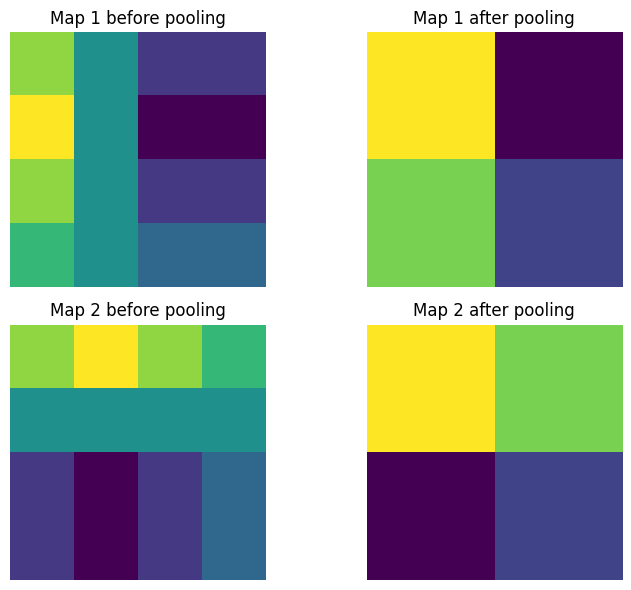

In [11]:

fig, axes = plt.subplots(2, 2, figsize=(8, 6))
axes[0,0].imshow(y[0,0].detach(), cmap="viridis")
axes[0,0].set_title("Map 1 before pooling")
axes[0,1].imshow(pooled[0,0].detach(), cmap="viridis")
axes[0,1].set_title("Map 1 after pooling")
axes[1,0].imshow(y[0,1].detach(), cmap="viridis")
axes[1,0].set_title("Map 2 before pooling")
axes[1,1].imshow(pooled[0,1].detach(), cmap="viridis")
axes[1,1].set_title("Map 2 after pooling")
for ax in axes.ravel():
    ax.axis("off")
plt.tight_layout()
plt.show()

**Max pooling** summarizes small regions by keeping the largest value.

Benefits:
- reduces dimensionality
- lowers computational cost
- adds some robustness to small translations

---

## 7. A mini CNN in PyTorch

Now we combine the pieces into a simple network.

In [12]:

class TinyCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 8, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(8, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(16 * 7 * 7, 32),
            nn.ReLU(),
            nn.Linear(32, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model = TinyCNN()
print(model)

TinyCNN(
  (features): Sequential(
    (0): Conv2d(1, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=32, bias=True)
    (2): ReLU()
    (3): Linear(in_features=32, out_features=10, bias=True)
  )
)


If the input is a `28x28` image:

- after the first pooling: `14x14`
- after the second pooling: `7x7`
- with 16 final channels: `16 x 7 x 7`

That is why the linear layer uses `16*7*7`.

---

## 8. What does each layer learn?

A common intuition:

- **Early layers**: edges, contrast, simple textures
- **Intermediate layers**: corners, repeated motifs, parts
- **Deep layers**: objects or more semantic configurations

### Business examples

1. **Retail**: detect wrongly placed products on shelves  
2. **Manufacturing**: find visual defects in parts  
3. **Agriculture**: distinguish healthy and damaged fruits  
4. **Insurance**: classify vehicle damage from photos

---

## 9. Key takeaways

- A CNN exploits the **spatial structure** of an image.
- Filters learn reusable local patterns.
- Each filter produces an activation map.
- Stride, padding, and pooling control size, detail, and cost.
- Deeper layers combine simple patterns into more complex concepts.

---

## 10. Suggested exercises

1. Replace the vertical kernel with a diagonal detector.  
2. Try `AvgPool2d` instead of `MaxPool2d`.  
3. Add a third convolutional layer to `TinyCNN`.  
4. Check how the number of parameters changes if you double the channels.